> 📅 Learning Progress: Day 12 of my Machine Learning journey
> In this project, I will use the dataset "Advertising Simple Dataset" from Jacky Huang on Kaggle.
> Jacky Huang as known as Jia Huang. He is the Lead Research Engineer at A*STAR | Author of Designing AI Agents | Applied GenAI, RAG, AI Agents, and Enterprise AI Systems
> I am learning machine learning based on the books he published.
>Linkedin: https://www.linkedin.com/in/jia-huang-74657145/

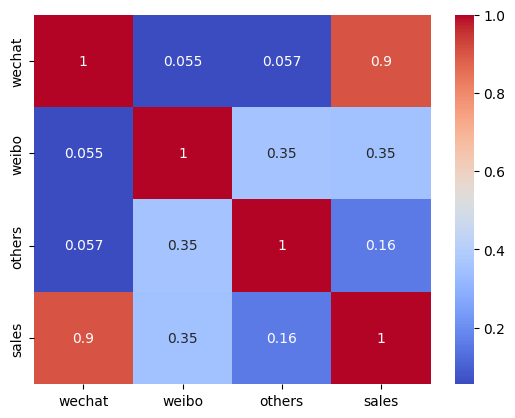

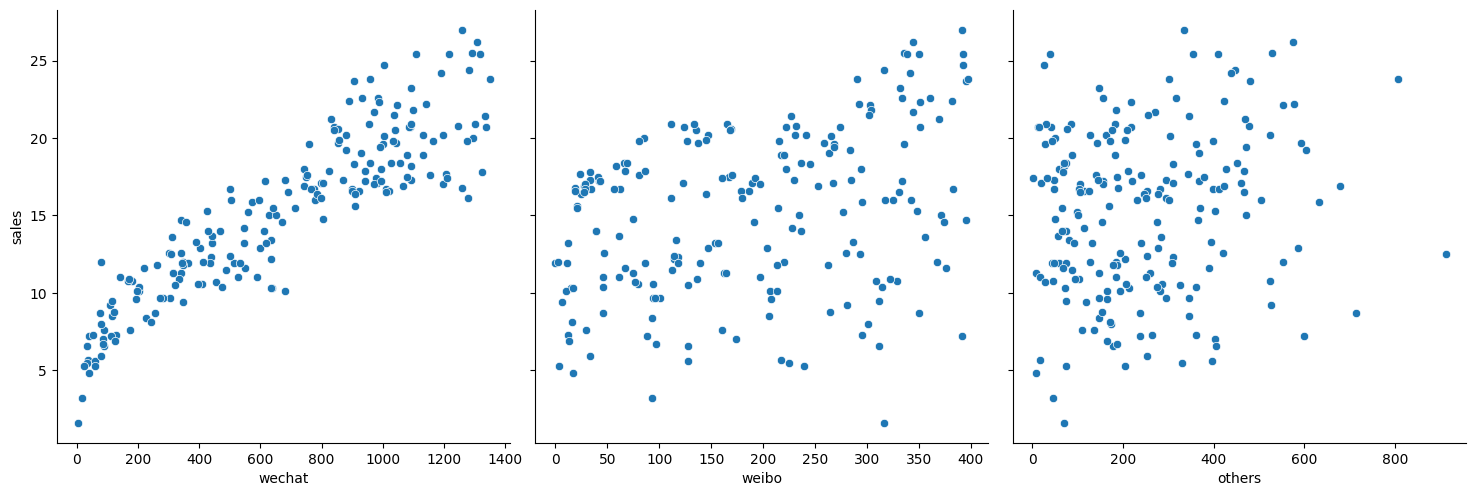

In [18]:
import numpy as np
import pandas as pd
df_ads=pd.read_csv('advertising.csv')
df_ads.head() #this will display the first 5 rows of the dataframe

import matplotlib.pyplot as plt
import seaborn as sns #Seaborn is a Python data visualization library based on matplotlib. 
sns.heatmap(df_ads.corr(),cmap='coolwarm',annot=True)
plt.show()
# Now, we can see the correlation between the features and the target variable.
# In our case, we can see wechat and sales have a strong positive correlation, 0.9.
# This means that as wechat increases, sales also increases.

# height is the height of each plot, aspect is the aspect ratio of each plot, kind is the type of plot, in this case scatter plot.
sns.pairplot(df_ads,x_vars=['wechat','weibo','others'],y_vars='sales',height=5,aspect=1,kind='scatter')

plt.show()

In [19]:
x=np.array(df_ads.wechat)
y=np.array(df_ads.sales)
print('Dimension of x:', x.ndim)
print('shape of x:', x.shape) #(200,) means 200 rows and 1 column, this is 1D array
print('values of x:', x)

Dimension of x: 1
shape of x: (200,)
values of x: [ 304.4 1011.9 1091.1   85.5 1047.   940.9 1277.2   38.2  342.6  347.6
  980.1   39.1   39.6  889.1  633.8  527.8  203.4  499.6  633.4  437.7
  334.  1132.   841.3  435.4  627.4  599.2  321.2  571.9  758.9  799.4
  314.   108.3  339.9  619.7  227.5  347.2  774.4 1003.3   60.1   88.3
 1280.4  743.9  805.4  905.    76.9 1088.8  670.2  513.7 1067.    89.2
  130.1  113.8  195.7 1000.1  283.5 1245.3  681.1  341.7  743.   976.9
 1308.6  953.7 1196.2  488.7 1027.4  830.8  984.6  143.3 1092.5  993.7
 1290.4  638.4  355.8  854.5    3.2  615.2   53.2  401.8 1348.6   78.3
 1188.9 1206.7  899.1  364.9  854.9 1099.7  909.1 1293.6  311.2  411.3
  881.3 1091.5   18.7  921.4 1214.4 1038.8  427.2  116.5  879.1  971.
  899.1  114.2   78.3   59.6  748.5  681.6  261.6 1083.8 1322.7  753.5
 1259.9 1080.2   33.2  909.1 1092.5 1208.5  766.2  467.3  611.1  202.5
   24.6  442.3 1301.3  314.9  634.7  408.1  560.1  503.7 1154.8 1130.2
  932.8  958.7 1044.2 1274.9

In [20]:
# For numerical datasets with regression problems, the standard format is to have the features in a 2D array with shape (samples, features). 
# In this case, we have 200 samples and 1 feature, so we need to reshape x to be a 2D array with shape (200, 1).
x=x.reshape((len(x),1))
y=y.reshape((len(y),1))
print('Dimension of x after reshape:', x.ndim)
print('shape of x after reshape:', x.shape) #(200,1) means 200 rows and 1 column, this is 2D array
print('values of x after reshape:', x)

Dimension of x after reshape: 2
shape of x after reshape: (200, 1)
values of x after reshape: [[ 304.4]
 [1011.9]
 [1091.1]
 [  85.5]
 [1047. ]
 [ 940.9]
 [1277.2]
 [  38.2]
 [ 342.6]
 [ 347.6]
 [ 980.1]
 [  39.1]
 [  39.6]
 [ 889.1]
 [ 633.8]
 [ 527.8]
 [ 203.4]
 [ 499.6]
 [ 633.4]
 [ 437.7]
 [ 334. ]
 [1132. ]
 [ 841.3]
 [ 435.4]
 [ 627.4]
 [ 599.2]
 [ 321.2]
 [ 571.9]
 [ 758.9]
 [ 799.4]
 [ 314. ]
 [ 108.3]
 [ 339.9]
 [ 619.7]
 [ 227.5]
 [ 347.2]
 [ 774.4]
 [1003.3]
 [  60.1]
 [  88.3]
 [1280.4]
 [ 743.9]
 [ 805.4]
 [ 905. ]
 [  76.9]
 [1088.8]
 [ 670.2]
 [ 513.7]
 [1067. ]
 [  89.2]
 [ 130.1]
 [ 113.8]
 [ 195.7]
 [1000.1]
 [ 283.5]
 [1245.3]
 [ 681.1]
 [ 341.7]
 [ 743. ]
 [ 976.9]
 [1308.6]
 [ 953.7]
 [1196.2]
 [ 488.7]
 [1027.4]
 [ 830.8]
 [ 984.6]
 [ 143.3]
 [1092.5]
 [ 993.7]
 [1290.4]
 [ 638.4]
 [ 355.8]
 [ 854.5]
 [   3.2]
 [ 615.2]
 [  53.2]
 [ 401.8]
 [1348.6]
 [  78.3]
 [1188.9]
 [1206.7]
 [ 899.1]
 [ 364.9]
 [ 854.9]
 [1099.7]
 [ 909.1]
 [1293.6]
 [ 311.2]
 [ 411.3]
 [ 881

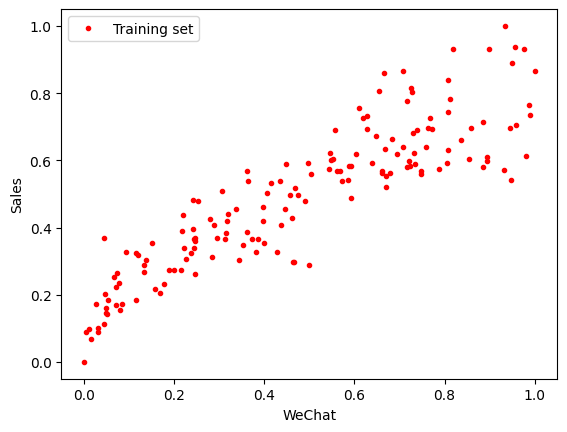

In [38]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

# Normalization is a technique to scale the data to a specific range, usually [0, 1].
def scaler(train,test):
    min = train.min(axis=0) 
    max = train.max(axis=0)
    gap = max - min # Calculate the range of the training set
    train -= min #All the values in the training set are subtracted by the minimum value of the training set.
    train /= gap #All the values in the training set are divided by the range of the training set.
    test -= min #All the values in the testing set are subtracted by the minimum value of the training set.
    test /= gap #All the values in the testing set are divided by the range of the training set.
    return train,test

x_train,x_test=scaler(x_train,x_test) #Normalize the training and testing sets using the scaler function defined above.
y_train,y_test=scaler(y_train,y_test) #Normalize the training and testing sets using the scaler function defined above.

# Now, we can visualize the training set and testing set using a scatter plot.
plt.plot(x_train,y_train,'r.',label='Training set') #Plot the training set in red color with label 'Training set'
plt.xlabel('WeChat') #Set the x-axis label to 'WeChat'
plt.ylabel('Sales') #Set the y-axis label to 'Sales'
plt.legend() #Display the legend
plt.show() #Display the plot

